In [1]:
!pip install kaggle
!pip install SimpleITK opencv-python tensorflow matplotlib numpy


                                              0.0/181.2 kB ? eta -:--:--
     --------                              41.0/181.2 kB 991.0 kB/s eta 0:00:01
     -----------------------                112.6/181.2 kB 1.6 MB/s eta 0:00:01
     -------------------------------------- 181.2/181.2 kB 1.8 MB/s eta 0:00:00
                                              0.0/78.2 kB ? eta -:--:--
     ---------------------------------------- 78.2/78.2 kB 4.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


                                              0.0/18.8 MB ? eta -:--:--
                                             0.0/18.8 MB 653.6 kB/s eta 0:00:29
                                              0.1/18.8 MB 1.3 MB/s eta 0:00:15
                                              0.3/18.8 MB 2.1 MB/s eta 0:00:09
     -                                        0.7/18.8 MB 3.9 MB/s eta 0:00:05
     ---                                      1.6/18.8 MB 7.4 MB/s eta 0:00:03
     ---                                      1.8/18.8 MB 8.2 MB/s eta 0:00:03
     ---                                      1.8/18.8 MB 8.2 MB/s eta 0:00:03
     --------                                 4.1/18.8 MB 11.3 MB/s eta 0:00:02
     ---------                                4.4/18.8 MB 10.9 MB/s eta 0:00:02
     -----------                              5.5/18.8 MB 12.1 MB/s eta 0:00:02
     ------------                             5.9/18.8 MB 12.1 MB/s eta 0:00:02
     -------------                            6.3/18.8

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.1.3 which is incompatible.

[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Tạo cấu trúc thư mục
#============================

import os

base_dir = "brain_project"
subdirs = [
    "data/images/train",
    "data/masks/train",
    "data/images/val",
    "data/masks/val",
    "models",
    "results",
    "src"
]

for sub in subdirs:
    os.makedirs(os.path.join(base_dir, sub), exist_ok=True)

print("✅ Cấu trúc thư mục đã được tạo:")
for root, dirs, files in os.walk(base_dir):
    level = root.replace(base_dir, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")


✅ Cấu trúc thư mục đã được tạo:
brain_project/
    data/
        images/
            train/
            val/
        masks/
            train/
            val/
    models/
    results/
    src/


In [3]:
# Cấu hình Kaggle API
# ========================

import shutil, os
from tkinter import Tk
from tkinter.filedialog import askopenfilename

Tk().withdraw()
print("📁 Hãy chọn file kaggle.json bạn vừa tải về:")
kaggle_file = askopenfilename()

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
shutil.copy(kaggle_file, os.path.expanduser("~/.kaggle/kaggle.json"))
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("✅ Đã cài đặt kaggle.json thành công!")


📁 Hãy chọn file kaggle.json bạn vừa tải về:
✅ Đã cài đặt kaggle.json thành công!


In [4]:
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation -p brain_project/data
!unzip brain_project/data/lgg-mri-segmentation.zip -d brain_project/data/lgg-mri-segmentation

Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0




  0%|          | 0.00/714M [00:00<?, ?B/s]
 20%|#9        | 142M/714M [00:00<00:00, 1.49GB/s]
 41%|####1     | 295M/714M [00:00<00:00, 1.55GB/s]
 65%|######5   | 467M/714M [00:00<00:00, 1.66GB/s]
 88%|########7 | 626M/714M [00:01<00:00, 255MB/s] 
100%|##########| 714M/714M [00:01<00:00, 404MB/s]
'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [5]:
import zipfile
import os

zip_path = "brain_project/data/lgg-mri-segmentation.zip"
extract_dir = "brain_project/data/lgg-mri-segmentation"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ Giải nén thành công vào:", extract_dir)


✅ Giải nén thành công vào: brain_project/data/lgg-mri-segmentation


In [7]:
# Chuyển mask và image vào tập train
#=====================================

import shutil
from tqdm import tqdm

input_root = "brain_project/data\lgg-mri-segmentation\kaggle_3m"
output_img = "brain_project/data/images/train"
output_mask = "brain_project/data/masks/train"

os.makedirs(output_img, exist_ok=True)
os.makedirs(output_mask, exist_ok=True)

folders = sorted(os.listdir(input_root))[:100]  # lấy 100 bệnh nhân

for folder in tqdm(folders, desc="Copying .tif files"):
    folder_path = os.path.join(input_root, folder)
    if not os.path.isdir(folder_path):
        continue
    for file in os.listdir(folder_path):
        if file.endswith(".tif"):
            src = os.path.join(folder_path, file)
            if "mask" in file:
                dst = os.path.join(output_mask, f"{folder}_{file}")
            else:
                dst = os.path.join(output_img, f"{folder}_{file}")
            shutil.copy(src, dst)
 

Copying .tif files: 100%|███████████████████████████████████████████████████████████| 100/100 [01:20<00:00,  1.24it/s]


Ảnh MRI: brain_project/data/images/train\TCGA_DU_7294_19890104_TCGA_DU_7294_19890104_24.tif
Mask: brain_project/data/masks/train\TCGA_DU_7294_19890104_TCGA_DU_7294_19890104_24_mask.tif
Kiểu dữ liệu ảnh: <class 'numpy.ndarray'>
Kích thước ảnh: (256, 256)


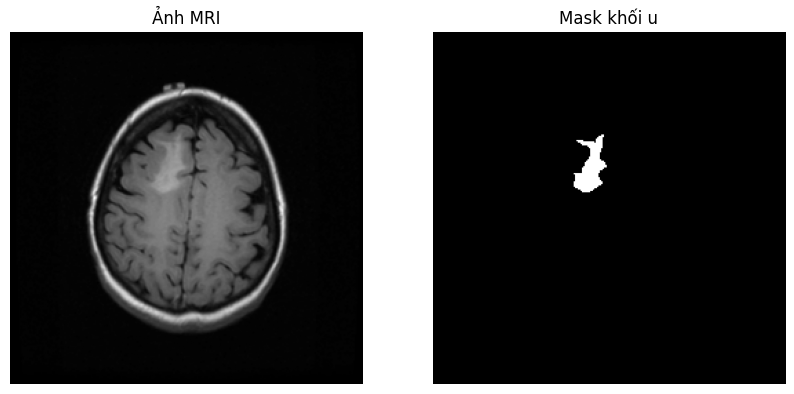

In [22]:
# Kiểm tra ảnh mẫu
#==================================

import random
import matplotlib.pyplot as plt
import cv2
import os

# Lấy ngẫu nhiên 1 mask
sample_mask = random.choice(os.listdir(output_mask))

# Tên ảnh tương ứng (bỏ phần "_mask")
sample_img = sample_mask.replace("_mask", "")

img_path = os.path.join(output_img, sample_img)
mask_path = os.path.join(output_mask, sample_mask)

print("Ảnh MRI:", img_path)
print("Mask:", mask_path)

# Đọc ảnh
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)


print("Kiểu dữ liệu ảnh:", type(img))
print("Kích thước ảnh:", img.shape if img is not None else "Không tồn tại")

# Hiển thị
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Ảnh MRI")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Mask khối u")
plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.show()


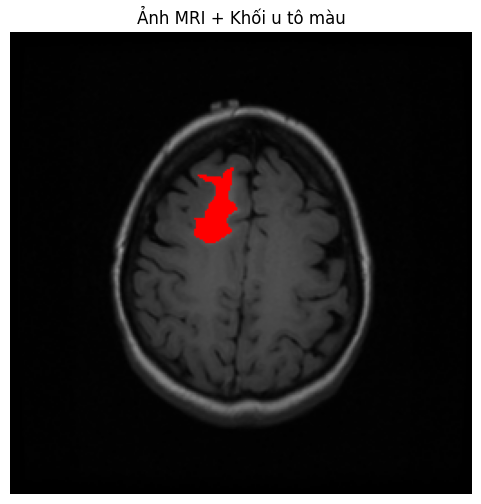

In [23]:
import cv2
import matplotlib.pyplot as plt

# Đọc lại ảnh
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

# Tạo ảnh overlay (màu đỏ cho vùng u)
overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
overlay[mask > 0] = [255, 0, 0]  # vùng u tô đỏ

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.title("Ảnh MRI + Khối u tô màu")
plt.axis('off')
plt.show()


In [5]:
# Cấu hình và đọc dữ liệu
#===================================

import tensorflow as tf
from tensorflow.keras.utils import img_to_array, load_img
import numpy as np
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

image_dir = "brain_project/data/images/train"
mask_dir = "brain_project/data/masks/train"

# Đọc tất cả ảnh và mask, resize về kích thước chuẩn (256x256) 
IMG_HEIGHT, IMG_WIDTH = 256, 256

def load_image(path):
    img = load_img(path, color_mode="grayscale", target_size=(IMG_HEIGHT, IMG_WIDTH))
    img = img_to_array(img) / 255.0
    return img

def load_mask(path):
    mask = load_img(path, color_mode="grayscale", target_size=(IMG_HEIGHT, IMG_WIDTH))
    mask = img_to_array(mask)
    mask = (mask > 0).astype(np.float32)  # nhị phân hóa: vùng u = 1
    return mask

images = []
masks = []

for mask_name in os.listdir(mask_dir):
    mask_path = os.path.join(mask_dir, mask_name)
    img_name = mask_name.replace("_mask", "")
    img_path = os.path.join(image_dir, img_name)

    if os.path.exists(img_path):
        images.append(load_image(img_path))
        masks.append(load_mask(mask_path))

X = np.array(images)
Y = np.array(masks)

print("Kích thước X:", X.shape)
print("Kích thước Y:", Y.shape)

# Chia train/validation
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " | Val:", X_val.shape)


Kích thước X: (3531, 256, 256, 1)
Kích thước Y: (3531, 256, 256, 1)
Train: (2824, 256, 256, 1)  | Val: (707, 256, 256, 1)


In [7]:
# Xây dựng mô hình U-Net có BatchNorm và Dropout để giảm overfitting
# ===================================================================

from tensorflow.keras import layers, models, regularizers

def conv_block(x, filters, dropout_rate=0.1):
    x = layers.Conv2D(filters, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)

    x = layers.Conv2D(filters, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)

    x = layers.Dropout(dropout_rate)(x)
    return x

def attention_gate(x, g, filters):
    theta_x = layers.Conv2D(filters, (1,1), padding='same')(x)
    phi_g = layers.Conv2D(filters, (1,1), padding='same')(g)
    add = layers.add([theta_x, phi_g])
    act = layers.Activation('relu')(add)
    psi = layers.Conv2D(1, (1,1), padding='same', activation='sigmoid')(act)
    return layers.multiply([x, psi])

def unet_attention(input_size=(256,256,1), dropout_rate=0.1):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = conv_block(inputs, 16, dropout_rate)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = conv_block(p1, 32, dropout_rate)
    p2 = layers.MaxPooling2D((2,2))(c2)

    c3 = conv_block(p2, 64, dropout_rate)
    p3 = layers.MaxPooling2D((2,2))(c3)

    c4 = conv_block(p3, 128, dropout_rate)
    p4 = layers.MaxPooling2D((2,2))(c4)

    # Bottleneck
    bn = conv_block(p4, 256, dropout_rate)

    # Decoder với Attention
    u5 = layers.Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(bn)
    a4 = attention_gate(c4, u5, 128)
    u5 = layers.concatenate([u5, a4])
    c5 = conv_block(u5, 128, dropout_rate)

    u6 = layers.Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(c5)
    a3 = attention_gate(c3, u6, 64)
    u6 = layers.concatenate([u6, a3])
    c6 = conv_block(u6, 64, dropout_rate)

    u7 = layers.Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(c6)
    a2 = attention_gate(c2, u7, 32)
    u7 = layers.concatenate([u7, a2])
    c7 = conv_block(u7, 32, dropout_rate)

    u8 = layers.Conv2DTranspose(16, (2,2), strides=(2,2), padding='same')(c7)
    a1 = attention_gate(c1, u8, 16)
    u8 = layers.concatenate([u8, a1])
    c8 = conv_block(u8, 16, dropout_rate)

    outputs = layers.Conv2D(1, (1,1), activation='sigmoid')(c8)

    return models.Model(inputs, outputs)



In [8]:
# Lost function kết hợp Dice + BCE

import tensorflow as tf

def dice_loss(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - ((2. * intersection + smooth) /
                (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth))

def combined_loss(y_true, y_pred):
    return 0.5 * dice_loss(y_true, y_pred) + \
           0.5 * tf.keras.losses.binary_crossentropy(y_true, y_pred)


In [9]:
# Huấn luyện
# ===============

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

model = unet_attention(input_size=(256,256,1), dropout_rate=0.2)
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=combined_loss,
              metrics=['accuracy'])

callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint('best_mri_unet.h5', save_best_only=True)
]

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=50,
    batch_size=8,
    callbacks=callbacks
)


Epoch 1/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.8388 - loss: 0.8353

353/353 ━━━━━━━━━━━━━━━━━━━━ 259s 708ms/step - accuracy: 0.9210 - loss: 0.7685 - val_accuracy: 0.9902 - val_loss: 0.7114 - learning_rate: 1.0000e-04
Epoch 2/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 675ms/step - accuracy: 0.9812 - loss: 0.6848

353/353 ━━━━━━━━━━━━━━━━━━━━ 252s 713ms/step - accuracy: 0.9808 - loss: 0.6721 - val_accuracy: 0.9899 - val_loss: 0.6479 - learning_rate: 1.0000e-04
Epoch 3/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.9819 - loss: 0.6321

353/353 ━━━━━━━━━━━━━━━━━━━━ 253s 716ms/step - accuracy: 0.9824 - loss: 0.6249 - val_accuracy: 0.9804 - val_loss: 0.6142 - learning_rate: 1.0000e-04
Epoch 4/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.9833 - loss: 0.5952

353/353 ━━━━━━━━━━━━━━━━━━━━ 253s 717ms/step - accuracy: 0.9842 - loss: 0.5872 - val_accuracy: 0.9922 - val_loss: 0.5741 - learning_rate: 1.0000e-04
Epoch 5/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - accuracy: 0.9868 - loss: 0.5603

...

353/353 ━━━━━━━━━━━━━━━━━━━━ 255s 723ms/step - accuracy: 0.9976 - loss: 0.1492 - val_accuracy: 0.9959 - val_loss: 0.2245 - learning_rate: 5.0000e-05
Epoch 27/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.9977 - loss: 0.1480

353/353 ━━━━━━━━━━━━━━━━━━━━ 256s 726ms/step - accuracy: 0.9976 - loss: 0.1415 - val_accuracy: 0.9961 - val_loss: 0.2151 - learning_rate: 5.0000e-05
Epoch 28/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 255s 723ms/step - accuracy: 0.9977 - loss: 0.1459 - val_accuracy: 0.9947 - val_loss: 0.3055 - learning_rate: 5.0000e-05
Epoch 29/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 257s 729ms/step - accuracy: 0.9977 - loss: 0.1370 - val_accuracy: 0.9961 - val_loss: 0.2227 - learning_rate: 5.0000e-05
Epoch 30/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 260s 738ms/step - accuracy: 0.9978 - loss: 0.1383 - val_accuracy: 0.9960 - val_loss: 0.2228 - learning_rate: 5.0000e-05
Epoch 31/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 255s 723ms/step - accuracy: 0.9978 - loss: 0.1365 - val_accuracy: 0.9957 - val_loss: 0.2369 - learning_rate: 5.0000e-05
Epoch 32/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - accuracy: 0.9979 - loss: 0.1309

353/353 ━━━━━━━━━━━━━━━━━━━━ 255s 724ms/step - accuracy: 0.9978 - loss: 0.1347 - val_accuracy: 0.9965 - val_loss: 0.1989 - learning_rate: 5.0000e-05
Epoch 33/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 253s 718ms/step - accuracy: 0.9978 - loss: 0.1307 - val_accuracy: 0.9960 - val_loss: 0.2143 - learning_rate: 5.0000e-05
Epoch 34/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 254s 719ms/step - accuracy: 0.9977 - loss: 0.1368 - val_accuracy: 0.9958 - val_loss: 0.2371 - learning_rate: 5.0000e-05
Epoch 35/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 256s 726ms/step - accuracy: 0.9978 - loss: 0.1286 - val_accuracy: 0.9956 - val_loss: 0.2460 - learning_rate: 5.0000e-05
Epoch 36/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.9978 - loss: 0.1363

353/353 ━━━━━━━━━━━━━━━━━━━━ 256s 726ms/step - accuracy: 0.9978 - loss: 0.1309 - val_accuracy: 0.9964 - val_loss: 0.1985 - learning_rate: 5.0000e-05
Epoch 37/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 257s 728ms/step - accuracy: 0.9979 - loss: 0.1318 - val_accuracy: 0.9962 - val_loss: 0.2134 - learning_rate: 5.0000e-05
Epoch 38/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - accuracy: 0.9978 - loss: 0.1197

353/353 ━━━━━━━━━━━━━━━━━━━━ 261s 739ms/step - accuracy: 0.9979 - loss: 0.1209 - val_accuracy: 0.9966 - val_loss: 0.1892 - learning_rate: 5.0000e-05
Epoch 39/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 255s 722ms/step - accuracy: 0.9980 - loss: 0.1175 - val_accuracy: 0.9959 - val_loss: 0.2314 - learning_rate: 5.0000e-05
Epoch 40/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 256s 724ms/step - accuracy: 0.9978 - loss: 0.1332 - val_accuracy: 0.9960 - val_loss: 0.2272 - learning_rate: 5.0000e-05
Epoch 41/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 257s 727ms/step - accuracy: 0.9980 - loss: 0.1159 - val_accuracy: 0.9958 - val_loss: 0.2332 - learning_rate: 5.0000e-05
Epoch 42/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 258s 732ms/step - accuracy: 0.9981 - loss: 0.1179 - val_accuracy: 0.9959 - val_loss: 0.2259 - learning_rate: 5.0000e-05
Epoch 43/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 259s 735ms/step - accuracy: 0.9980 - loss: 0.1245 - val_accuracy: 0.9958 - val_loss: 0.2377 - learning_rate: 5.0000e-05
Epoch 44/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 257s 

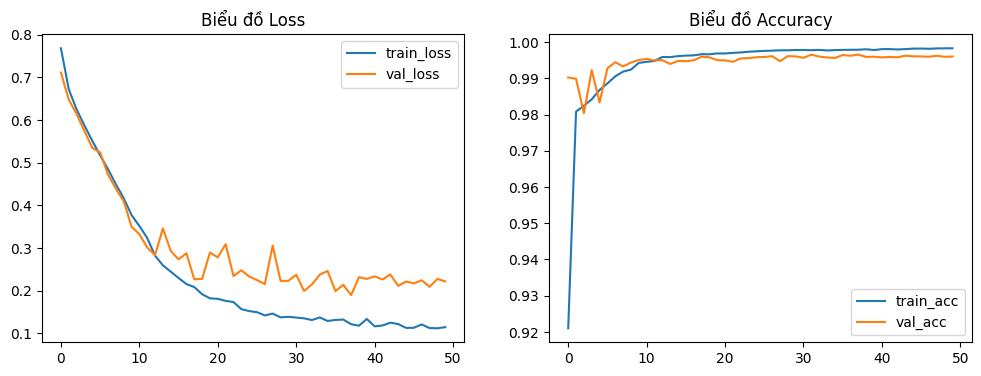

In [10]:
# Vẽ kết quả học
# ===================

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Biểu đồ Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Biểu đồ Accuracy')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


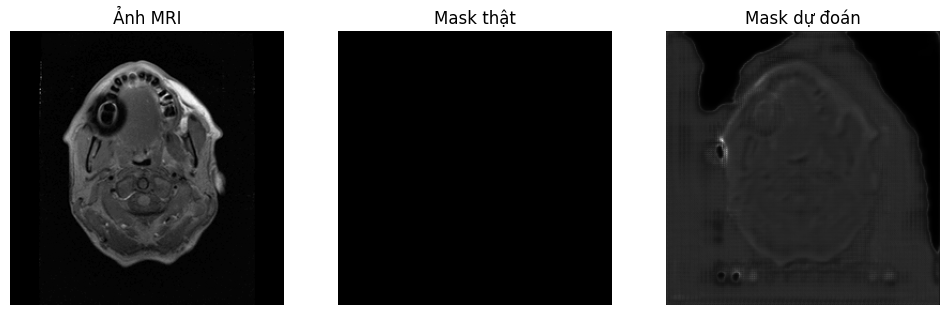

In [24]:
# Dự đoán và hiển thị kết quả
# ==============================

idx = np.random.randint(0, X_val.shape[0])
pred = model.predict(X_val[idx:idx+1])[0,:,:,0]

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Ảnh MRI")
plt.imshow(X_val[idx].squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Mask thật")
plt.imshow(Y_val[idx].squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Mask dự đoán")
plt.imshow(pred, cmap='gray')
plt.axis('off')

plt.show()


In [1]:
def visualize_prediction(X, Y_true, model, idx):
    pred = model.predict(X[idx:idx+1])[0]
    pred_bin = (pred > 0.5).astype(np.float32)

    plt.figure(figsize=(12,4))
    titles = ['Ảnh MRI', 'Mask thật', 'Mask dự đoán']
    for i, img in enumerate([X[idx,:,:,0], Y_true[idx,:,:,0], pred_bin[:,:,0]]):
        plt.subplot(1,3,i+1)
        plt.imshow(img, cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.show()


In [28]:
# Lưu toàn bộ model
model.save("brain_project/models/unet_brain_mri.h5")

print("✅ Đã lưu model tại: brain_project/models/unet_brain_mri.h5")

from tensorflow.keras.models import load_model
model = load_model("brain_project/models/unet_brain_mri.h5")

✅ Đã lưu model tại: brain_project/models/unet_brain_mri.h5


In [9]:
from tensorflow.keras import layers, models, regularizers

# ---- Mini Xception block ----
def mini_xception_block(x, filters, dropout_rate=0.1, l2_reg=1e-4):
    """
    Mini Xception-like block:
    - Residual: 1x1 conv -> BN
    - Main path: SeparableConv2D -> BN -> Activation -> SeparableConv2D -> BN
    - Add residual -> Activation -> Dropout
    """
    # Residual projection (1x1 conv) to match channels
    residual = layers.Conv2D(filters, (1,1), padding='same', use_bias=False,
                             kernel_regularizer=regularizers.l2(l2_reg))(x)
    residual = layers.BatchNormalization()(residual)
    
    # Main path: separable convs (đã sửa lỗi kernel_regularizer)
    x = layers.SeparableConv2D(
        filters, (3,3), padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(l2_reg),
        pointwise_regularizer=regularizers.l2(l2_reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    
    x = layers.SeparableConv2D(
        filters, (3,3), padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(l2_reg),
        pointwise_regularizer=regularizers.l2(l2_reg)
    )(x)
    x = layers.BatchNormalization()(x)
    
    # Add residual and activation
    x = layers.add([x, residual])
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(dropout_rate)(x)
    return x


# ---- Attention Gate ----
def attention_gate(x, g, filters):
    theta_x = layers.Conv2D(filters, (1,1), padding='same')(x)
    phi_g = layers.Conv2D(filters, (1,1), padding='same')(g)
    add = layers.add([theta_x, phi_g])
    act = layers.Activation('relu')(add)
    psi = layers.Conv2D(1, (1,1), padding='same', activation='sigmoid')(act)
    return layers.multiply([x, psi])


# ---- U-Net + Mini Xception + Attention ----
def unet_attention_mini_xception(input_size=(256,256,1), dropout_rate=0.1, l2_reg=1e-4):
    inputs = layers.Input(input_size)
    
    # Encoder (mini Xception blocks)
    c1 = mini_xception_block(inputs, 16, dropout_rate, l2_reg)
    p1 = layers.MaxPooling2D((2,2))(c1)
    
    c2 = mini_xception_block(p1, 32, dropout_rate, l2_reg)
    p2 = layers.MaxPooling2D((2,2))(c2)
    
    c3 = mini_xception_block(p2, 64, dropout_rate, l2_reg)
    p3 = layers.MaxPooling2D((2,2))(c3)
    
    c4 = mini_xception_block(p3, 128, dropout_rate, l2_reg)
    p4 = layers.MaxPooling2D((2,2))(c4)
    
    # Bottleneck
    bn = mini_xception_block(p4, 256, dropout_rate, l2_reg)
    
    # Decoder với Attention + mini-xception blocks
    u5 = layers.Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(bn)
    a4 = attention_gate(c4, u5, 128)
    u5 = layers.concatenate([u5, a4])
    c5 = mini_xception_block(u5, 128, dropout_rate, l2_reg)
    
    u6 = layers.Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(c5)
    a3 = attention_gate(c3, u6, 64)
    u6 = layers.concatenate([u6, a3])
    c6 = mini_xception_block(u6, 64, dropout_rate, l2_reg)
    
    u7 = layers.Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(c6)
    a2 = attention_gate(c2, u7, 32)
    u7 = layers.concatenate([u7, a2])
    c7 = mini_xception_block(u7, 32, dropout_rate, l2_reg)
    
    u8 = layers.Conv2DTranspose(16, (2,2), strides=(2,2), padding='same')(c7)
    a1 = attention_gate(c1, u8, 16)
    u8 = layers.concatenate([u8, a1])
    c8 = mini_xception_block(u8, 16, dropout_rate, l2_reg)
    
    # Output
    outputs = layers.Conv2D(1, (1,1), activation='sigmoid')(c8)
    model = models.Model(inputs, outputs)
    return model


# ---- Khởi tạo và xem mô hình ----
model = unet_attention_mini_xception(input_size=(128,128,1), dropout_rate=0.1)
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)            ┃ Output Shape        ┃      Param # ┃ Connected to         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3           │ (None, 128, 128, 1) │            0 │ -                    │
│ (InputLayer)            │                     │              │                      │
├─────────────────────────┼─────────────────────┼──────────────┼──────────────────────┤
│ separable_conv2d_37     │ (None, 128, 128,    │           25 │ input_layer_3[0][0]  │
│ (SeparableConv2D)       │ 16)                 │              │                      │
├─────────────────────────┼─────────────────────┼──────────────┼──────────────────────┤
│ batch_normalization_56  │ (None, 128, 128,    │           64 │ separable_conv2d_37… │
│ (BatchNormalization)    │ 16)                 │              │                      │
├─────────────────────────┼─────────────────────┼──────────────┼──────────────────────┤
│ leaky_re_lu_36          │ (None, 128, 128,    │            0 │ batch_normalization… │
│ (LeakyReLU)             │ 16)                 │              │                      │
├─────────────────────────┼─────────────────────┼──────────────┼──────────────────────┤
│ separable_conv2d_38     │ (None, 128, 128,    │          400 │ leaky_re_lu_36[0][0] │
│ (SeparableConv2D)       │ 16)                 │              │                      │
├─────────────────────────┼─────────────────────┼──────────────┼──────────────────────┤
│ conv2d_45 (Conv2D)      │ (None, 128, 128,    │           16 │ input_layer_3[0][0]  │
│                         │ 16)                 │              │                      │
├─────────────────────────┼─────────────────────┼──────────────┼──────────────────────┤
│ batch_normalization_57  │ (None, 128, 128,    │           64 │ separable_conv2d_38… │
│ (BatchNormalization)    │ 16)                 │              │                      │
├─────────────────────────┼─────────────────────┼──────────────┼──────────────────────┤
│ batch_normalization_55  │ (None, 128, 128,    │           64 │ conv2d_45[0][0]      │
│ (BatchNormalization)    │ 16)                 │              │                      │
├─────────────────────────┼─────────────────────┼──────────────┼──────────────────────┤
│ add_26 (Add)            │ (None, 128, 128,    │            0 │ batch_normalization… │
│                         │ 16)                 │              │ batch_normalization… │
├─────────────────────────┼─────────────────────┼──────────────┼──────────────────────┤
│ leaky_re_lu_37          │ (None, 128, 128,    │            0 │ add_26[0][0]         │
│ (LeakyReLU)             │ 16)                 │              │                      │
├─────────────────────────┼─────────────────────┼──────────────┼──────────────────────┤
│ dropout_18 (Dropout)    │ (None, 128, 128,    │            0 │ leaky_re_lu_37[0][0] │
│                         │ 16)                 │              │                      │
├─────────────────────────┼─────────────────────┼──────────────┼──────────────────────┤
│ max_pooling2d_8         │ (None, 64, 64, 16)  │            0 │ dropout_18[0][0]     │
│ (MaxPooling2D)          │                     │              │                      │
├─────────────────────────┼─────────────────────┼──────────────┼──────────────────────┤
│ separable_conv2d_39     │ (None, 64, 64, 32)  │          656 │ max_pooling2d_8[0][… │
│ (SeparableConv2D)       │                     │              │                      │
├─────────────────────────┼─────────────────────┼──────────────┼──────────────────────┤
│ batch_normalization_59  │ (None, 64, 64, 32)  │          128 │ separable_conv2d_39… │
│ (BatchNormalization)    │                     │              │                      │
├─────────────────────────┼─────────────────────┼──────────────┼──────────────────────┤
│ leaky_re_lu_38          │ (None, 64, 6

 Total params: 523,694 (2.00 MB)

 Trainable params: 519,278 (1.98 MB)

 Non-trainable params: 4,416 (17.25 KB)

In [12]:
import tensorflow as tf

# Dice loss
def dice_loss(y_true, y_pred, smooth=1e-6):
    """
    Tính Dice loss (1 - Dice coefficient)
    Dùng cho bài toán segmentation nhị phân.
    """
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    dice = (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )
    return 1 - dice


# BCE + Dice kết hợp
def combined_loss(y_true, y_pred, dice_weight=0.5, bce_weight=0.5):
    """
    Loss function kết hợp Binary Crossentropy và Dice Loss.
    Trọng số có thể điều chỉnh để phù hợp với dữ liệu.
    """
    # Clip y_pred để tránh log(0)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    
    # Binary crossentropy
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    
    # Dice loss
    dice = dice_loss(y_true, y_pred)
    
    # Kết hợp hai loại loss
    total_loss = dice_weight * dice + bce_weight * bce
    return total_loss


In [11]:
# Huấn luyện
# ===========================

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# ⚙️ Hàm dice_coef thêm vào metrics để theo dõi
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

# --- Khởi tạo mô hình ---
model = unet_attention_mini_xception(input_size=(256,256,1), dropout_rate=0.2)

# --- Compile ---
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=['accuracy', dice_coef]
)

# --- Callback ---
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_mri_unet_xception.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# --- Huấn luyện ---
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=50,
    batch_size=8,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - accuracy: 0.8705 - dice_coef: 0.0353 - loss: 0.8693
Epoch 1: val_loss improved from None to 0.76416, saving model to best_mri_unet_xception.h5


353/353 ━━━━━━━━━━━━━━━━━━━━ 299s 808ms/step - accuracy: 0.9258 - dice_coef: 0.0423 - loss: 0.7863 - val_accuracy: 0.9674 - val_dice_coef: 0.0304 - val_loss: 0.7642 - learning_rate: 1.0000e-04
Epoch 2/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 822ms/step - accuracy: 0.9780 - dice_coef: 0.0927 - loss: 0.6486
Epoch 2: val_loss improved from 0.76416 to 0.59888, saving model to best_mri_unet_xception.h5


353/353 ━━━━━━━━━━━━━━━━━━━━ 304s 862ms/step - accuracy: 0.9803 - dice_coef: 0.1103 - loss: 0.6267 - val_accuracy: 0.9882 - val_dice_coef: 0.1058 - val_loss: 0.5989 - learning_rate: 1.0000e-04
Epoch 3/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 840ms/step - accuracy: 0.9854 - dice_coef: 0.1810 - loss: 0.5641
Epoch 3: val_loss improved from 0.59888 to 0.51444, saving model to best_mri_unet_xception.h5


353/353 ━━━━━━━━━━━━━━━━━━━━ 311s 881ms/step - accuracy: 0.9860 - dice_coef: 0.1956 - loss: 0.5516 - val_accuracy: 0.9923 - val_dice_coef: 0.2323 - val_loss: 0.5144 - learning_rate: 1.0000e-04
Epoch 4/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 818ms/step - accuracy: 0.9878 - dice_coef: 0.2623 - loss: 0.5055
Epoch 4: val_loss improved from 0.51444 to 0.48614, saving model to best_mri_unet_xception.h5


353/353 ━━━━━━━━━━━━━━━━━━━━ 301s 853ms/step - accuracy: 0.9882 - dice_coef: 0.2774 - loss: 0.4950 - val_accuracy: 0.9909 - val_dice_coef: 0.2807 - val_loss: 0.4861 - learning_rate: 1.0000e-04
Epoch 5/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 811ms/step - accuracy: 0.9892 - dice_coef: 0.3380 - loss: 0.4576
Epoch 5: val_loss improved from 0.48614 to 0.44113, saving model to best_mri_unet_xception.h5


...

353/353 ━━━━━━━━━━━━━━━━━━━━ 311s 881ms/step - accuracy: 0.9972 - dice_coef: 0.7880 - loss: 0.1925 - val_accuracy: 0.9954 - val_dice_coef: 0.6175 - val_loss: 0.2920 - learning_rate: 2.5000e-05
Epoch 38/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0.9973 - dice_coef: 0.7985 - loss: 0.1867
Epoch 38: val_loss did not improve from 0.29198
353/353 ━━━━━━━━━━━━━━━━━━━━ 296s 837ms/step - accuracy: 0.9973 - dice_coef: 0.7991 - loss: 0.1865 - val_accuracy: 0.9952 - val_dice_coef: 0.5950 - val_loss: 0.3058 - learning_rate: 2.5000e-05
Epoch 39/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 776ms/step - accuracy: 0.9973 - dice_coef: 0.7906 - loss: 0.1906
Epoch 39: val_loss did not improve from 0.29198
353/353 ━━━━━━━━━━━━━━━━━━━━ 286s 811ms/step - accuracy: 0.9973 - dice_coef: 0.7821 - loss: 0.1948 - val_accuracy: 0.9953 - val_dice_coef: 0.6080 - val_loss: 0.2975 - learning_rate: 2.5000e-05
Epoch 40/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 788ms/step - accuracy: 0.9974 - dice_coef: 0.7949 - loss: 0.188

353/353 ━━━━━━━━━━━━━━━━━━━━ 292s 828ms/step - accuracy: 0.9973 - dice_coef: 0.8053 - loss: 0.1830 - val_accuracy: 0.9955 - val_dice_coef: 0.6288 - val_loss: 0.2855 - learning_rate: 2.5000e-05
Epoch 41/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - accuracy: 0.9973 - dice_coef: 0.8233 - loss: 0.1737
Epoch 41: val_loss did not improve from 0.28546
353/353 ━━━━━━━━━━━━━━━━━━━━ 295s 836ms/step - accuracy: 0.9973 - dice_coef: 0.8148 - loss: 0.1781 - val_accuracy: 0.9952 - val_dice_coef: 0.5973 - val_loss: 0.3040 - learning_rate: 2.5000e-05
Epoch 42/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.9972 - dice_coef: 0.7755 - loss: 0.1979
Epoch 42: val_loss did not improve from 0.28546
353/353 ━━━━━━━━━━━━━━━━━━━━ 285s 808ms/step - accuracy: 0.9973 - dice_coef: 0.7931 - loss: 0.1889 - val_accuracy: 0.9953 - val_dice_coef: 0.6112 - val_loss: 0.2953 - learning_rate: 2.5000e-05
Epoch 43/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.9972 - dice_coef: 0.8102 - loss: 0.180

353/353 ━━━━━━━━━━━━━━━━━━━━ 291s 824ms/step - accuracy: 0.9973 - dice_coef: 0.8021 - loss: 0.1840 - val_accuracy: 0.9956 - val_dice_coef: 0.6345 - val_loss: 0.2806 - learning_rate: 2.5000e-05
Epoch 45/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 868ms/step - accuracy: 0.9972 - dice_coef: 0.7691 - loss: 0.2007
Epoch 45: val_loss did not improve from 0.28057
353/353 ━━━━━━━━━━━━━━━━━━━━ 322s 911ms/step - accuracy: 0.9973 - dice_coef: 0.7748 - loss: 0.1975 - val_accuracy: 0.9950 - val_dice_coef: 0.5773 - val_loss: 0.3144 - learning_rate: 2.5000e-05
Epoch 46/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 908ms/step - accuracy: 0.9974 - dice_coef: 0.7731 - loss: 0.1981
Epoch 46: val_loss did not improve from 0.28057
353/353 ━━━━━━━━━━━━━━━━━━━━ 335s 948ms/step - accuracy: 0.9974 - dice_coef: 0.7925 - loss: 0.1884 - val_accuracy: 0.9953 - val_dice_coef: 0.6073 - val_loss: 0.2971 - learning_rate: 2.5000e-05
Epoch 47/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 878ms/step - accuracy: 0.9975 - dice_coef: 0.8145 - loss: 0.176

353/353 ━━━━━━━━━━━━━━━━━━━━ 317s 898ms/step - accuracy: 0.9974 - dice_coef: 0.8136 - loss: 0.1775 - val_accuracy: 0.9957 - val_dice_coef: 0.6430 - val_loss: 0.2762 - learning_rate: 2.5000e-05
Epoch 49/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.9975 - dice_coef: 0.8264 - loss: 0.1709
Epoch 49: val_loss did not improve from 0.27616
353/353 ━━━━━━━━━━━━━━━━━━━━ 285s 808ms/step - accuracy: 0.9974 - dice_coef: 0.8186 - loss: 0.1751 - val_accuracy: 0.9956 - val_dice_coef: 0.6376 - val_loss: 0.2792 - learning_rate: 2.5000e-05
Epoch 50/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.9973 - dice_coef: 0.7931 - loss: 0.1876
Epoch 50: val_loss improved from 0.27616 to 0.27459, saving model to best_mri_unet_xception.h5


353/353 ━━━━━━━━━━━━━━━━━━━━ 286s 809ms/step - accuracy: 0.9974 - dice_coef: 0.7967 - loss: 0.1858 - val_accuracy: 0.9958 - val_dice_coef: 0.6448 - val_loss: 0.2746 - learning_rate: 2.5000e-05
Restoring model weights from the end of the best epoch: 50.


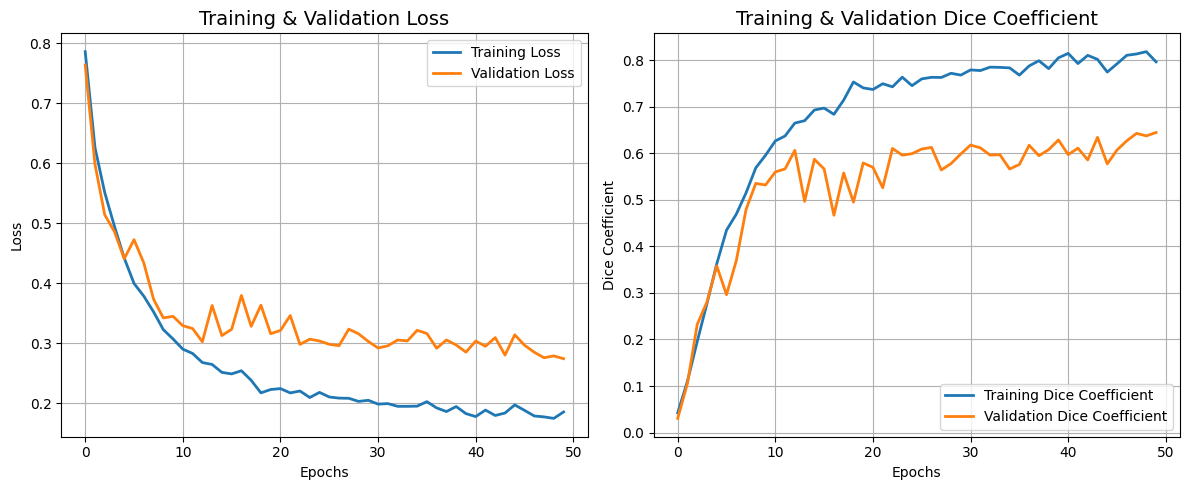

In [13]:
# ========================================
# 📊 VẼ BIỂU ĐỒ KẾT QUẢ HUẤN LUYỆN
# ========================================

import matplotlib.pyplot as plt

# Lấy lịch sử training
history_dict = history.history

# Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_dict['loss'], label='Training Loss', linewidth=2)
plt.plot(history_dict['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Training & Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Dice Coefficient
if 'dice_coef' in history_dict:
    plt.subplot(1, 2, 2)
    plt.plot(history_dict['dice_coef'], label='Training Dice Coefficient', linewidth=2)
    plt.plot(history_dict['val_dice_coef'], label='Validation Dice Coefficient', linewidth=2)
    plt.title('Training & Validation Dice Coefficient', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Dice Coefficient')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


In [4]:
# ✅ Lưu toàn bộ model
model.save("brain_project/models/unet_brain_mri.h5")
print("✅ Đã lưu model tại: brain_project/models/unet_brain_mri.h5")

# ✅ Nạp lại model đã lưu
from tensorflow.keras.models import load_model

# Vì dùng loss & metric tự định nghĩa, cần truyền custom_objects
model = load_model(
    "brain_project/models/unet_brain_mri.h5",
    custom_objects={
        'dice_loss': dice_loss,
        'combined_loss': combined_loss,
        'dice_coef': dice_coef
    }
)

print("✅ Đã load lại model thành công!")


NameError: name 'model' is not defined

In [3]:
from tensorflow.keras.models import load_model

# Truyền vào custom_objects
from tensorflow.keras import backend as K

def dice_loss(y_true, y_pred):
    # (định nghĩa lại hàm giống khi train)
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    dice = (2. * intersection + 1e-6) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + 1e-6
    )
    return 1 - dice

def combined_loss(y_true, y_pred, dice_weight=0.5, bce_weight=0.5):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    dice = dice_loss(y_true, y_pred)
    return dice_weight * dice + bce_weight * bce

# ---- Gọi lại model ----
model = load_model(
    "brain_project/models/unet_brain_mri.h5",
    custom_objects={'combined_loss': combined_loss, 'dice_loss': dice_loss}
)

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)    │ (None, 256, 256, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ separable_conv2d_55           │ (None, 256, 256, 16)      │              25 │ input_layer_4[0][0]        │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_83        │ (None, 256, 256, 16)      │              64 │ separable_conv2d_55[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_54 (LeakyReLU)    │ (None, 256, 256, 16)      │               0 │ batch_normalization_83[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ separable_conv2d_56           │ (None, 256, 256, 16)      │             400 │ leaky_re_lu_54[0][0]       │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_67 (Conv2D)            │ (None, 256, 256, 16)      │              16 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_84        │ (None, 256, 256, 16)      │              64 │ separable_conv2d_56[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_82        │ (None, 256, 256, 16)      │              64 │ conv2d_67[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_39 (Add)                  │ (None, 256, 256, 16)      │               0 │ batch_normalization_84[0]… │
│                               │                           │                 │ batch_normalization_82[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_55 (LeakyReLU)    │ (None, 256, 256, 16)      │               0 │ add_39[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_27 (Dropout)          │ (None, 256, 256, 16)      │               0 │ leaky_re_lu_55[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_12              │ (None, 128, 128, 16)      │               0 │ dropout_27[0][0]           │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ separable_conv2d_57           │ (None, 128, 128, 32)      │             656 │ max_pooling2d_12[0][0]     │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 523,696 (2.00 MB)

 Trainable params: 519,278 (1.98 MB)

 Non-trainable params: 4,416 (17.25 KB)

 Optimizer params: 2 (12.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 664ms/step


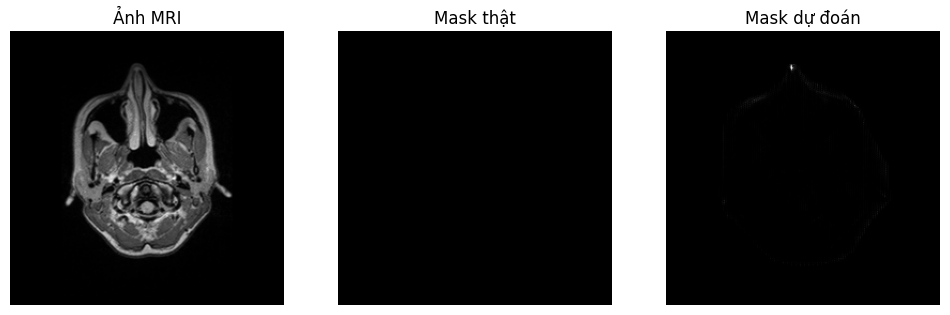

In [24]:
# Dự đoán và hiển thị kết quả
# ==============================

idx = np.random.randint(0, X_val.shape[0])
pred = model.predict(X_val[idx:idx+1])[0,:,:,0]

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Ảnh MRI")
plt.imshow(X_val[idx].squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Mask thật")
plt.imshow(Y_val[idx].squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Mask dự đoán")
plt.imshow(pred, cmap='gray')
plt.axis('off')

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


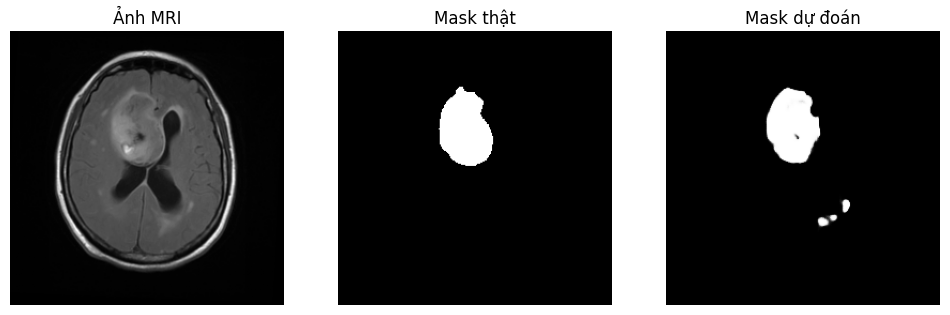

In [10]:
# Dự đoán và hiển thị kết quả
# ==============================

idx = np.random.randint(0, X_val.shape[0])
pred = model.predict(X_val[idx:idx+1])[0,:,:,0]

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Ảnh MRI")
plt.imshow(X_val[idx].squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Mask thật")
plt.imshow(Y_val[idx].squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Mask dự đoán")
plt.imshow(pred, cmap='gray')
plt.axis('off')

plt.show()


In [2]:
!pip install tensorflow tensorflow-hub


  Using cached tensorflow-2.20.0-cp311-cp311-win_amd64.whl (331.8 MB)
  Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl (30 kB)
  Using cached tf_keras-2.20.1-py3-none-any.whl (1.7 MB)



[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
